# 08. 비용 기반 임계값 — 성능이 아니라 기대비용으로 정한다

미탐(FN) 1건 1,700만원 vs 오탐(FP) 1건 5천~5만원. **최대 340배 비대칭**이다.
Macro-F1 만으로는 “이 임계값을 운영에 써도 되는가”에 답할 수 없다.

> **출처** — `원본/최종_3차_통합분석.ipynb` (코드 셀 **1개**, 29,946자)
>
> 원본은 `RUN_PART1`~`RUN_PART4` 플래그로 5개 파트를 한 셀에서 켜고 끄는 구조였다.
> 이 저장소는 그 플래그 경계를 그대로 살려 파트별 노트북으로 분리하고,
> **원본 실행 출력(표·그래프)을 해당 셀에 그대로 옮겨 붙였다.**
> 따라서 데이터가 없어도 결과를 볼 수 있고, 데이터가 있으면 그대로 재실행된다.



### 재현 조건

| 항목 | 값 |
|---|---|
| 입력 | `data/X_tr.parquet` · `X_va.parquet` · `y_tr.parquet` · `y_va.parquet` (**3차 전처리**) |
| 형상 | train `(96,140 × 58)` / valid `(23,860 × 58)` |
| 정상 클래스 | `12` (= `m`) |
| 모델 | `LGBMClassifier` · `n_estimators=300` · `class_weight="balanced"` · `random_state=42` |
| 학습 시간 | 약 13초 (4스레드) |

> `data/` 는 용량(141MB) 때문에 저장소에 포함하지 않았다 — `data/README.md` 참고.
> 아래 셀의 출력은 **원본 실행 결과 그대로**다.

> ⚠️ 원본의 `if RUN_PARTn:` 가드는 제거하고 들여쓰기를 풀었다.
> 파트별 노트북이므로 그 파트는 항상 실행된다 — **로직은 원본과 동일**하다.


## 0. 공통 설정 · 데이터 로드 · 모델 학습

다섯 개 노트북이 모두 이 블록으로 시작한다. 원본 통합 셀의 `[0]` 구획이다.


In [ ]:
# [0] 설정 · 데이터 로드 · 모델 학습 (여기부터 순서대로 실행)
import warnings, time, logging
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ===== 설정 =====
DATA_DIR = "../../data"        # 3차 전처리 parquet 폴더 (원본 실행 경로:
                               #   /mnt/c/Users/dkstj/Desktop/test_uv/3차 전처리 파일)
SEED = 42
LGBM_THREADS = 4
N_ESTIMATORS = 300             # 느리면 150~200 (수치가 달라짐)

RUN_PART1 = True               # 산출물 4종
RUN_COMPARE = True             # 모델 비교(한방 기본/임계값 · 2계층 기본/임계값) — 2계층 학습 포함
RUN_PART2 = True               # 비용기반 임계값
RUN_PART3 = True               # 규칙기반 + ML 결합
RUN_PART4 = True               # 생성 AI 합성데이터 증강 비교 (느림: sdv 필요)

LEAK_COLS = ["is_fraud", "fraud_type", "label", "y"]      # 정답 라벨 자동 제거
LOOKAHEAD_SUSPECT = ["Account_one_month_max_amount", "Account_one_month_std_dev",
                     "Account_dawn_one_month_max_amount", "Account_dawn_one_month_std_dev",
                     "Amount_vs_monthly_max_ratio"]        # 남아 있으면 경고만

# 비용 가정 (팀 합의값으로 교체)
FN_COST = 17_000_000
FP_SCENARIOS = {"A (FP 5k)": 5_000, "B (FP 10k)": 10_000, "C (FP 50k)": 50_000}
MACRO_MIN = 0.60               # 최종 채택 조건: Macro-F1 최소기준선
AMOUNT_COL = "Transaction_Amount_abs"

# 임계값 격자
THR_FULL = [0.9, 0.7, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01,
            0.005, 0.003, 0.002, 0.001, 0.0005, 0.0002, 0.0]
THR_BARS = [0.0, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.008, 0.01, 0.02, 0.03]
THR_COLLAPSE = [0.0, 0.00001, 0.00002, 0.00005, 0.0001, 0.00015, 0.0002]

SHAP_SAMPLE = 2000
TOP_FEATURES = 15

# [3] 하이브리드
RULE_MIN_SUPPORT = 15
PRECISION_SCAN = [0.85, 0.70, 0.50, 0.30]
CONT_Q_HI, CONT_Q_LO = [0.90, 0.95, 0.99], [0.01, 0.05, 0.10]
VERIFIED_COMPOSITES = ["large_deposit_and_remote_control", "unused_terminal_and_internet",
                       "limit_check_then_transfer", "suspended_recipient_and_withdrawal",
                       "new_recipient_and_large_amount", "weak_signal_composite_score"]
BOOST_WEIGHT = 0.30

# [4] 증강
TRAIN_SUBSAMPLE_NORMAL = 20000
TARGET_PER_CLASS = 500
GEN_EPOCHS = 300

LGBM_PARAMS = dict(n_estimators=N_ESTIMATORS, learning_rate=0.05, num_leaves=31,
                   subsample=0.9, colsample_bytree=0.9, class_weight="balanced",
                   random_state=SEED, n_jobs=LGBM_THREADS, verbose=-1)
lab = lambda i: chr(ord("a") + int(i))
np.random.seed(SEED)

In [ ]:
# ===== 표시 유틸 =====
def _setup_plt():
    import matplotlib
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
    import matplotlib.pyplot as plt
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
    matplotlib.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    return plt


def _table(df, caption=""):
    """VS Code/Jupyter면 표로 렌더링(출력 잘림 방지), 아니면 텍스트."""
    if caption:
        print(f"\n[{caption}]")
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            from IPython.display import display
            display(df); return
    except Exception:
        pass
    print(df.to_string(index=False))


def _head(title):
    print("\n" + "=" * 74); print(f" {title}"); print("=" * 74)

In [ ]:
# ===== 데이터 로드 =====
from lightgbm import LGBMClassifier
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

_d = Path(DATA_DIR)
X_tr = pd.read_parquet(_d / "X_tr.parquet").reset_index(drop=True)
X_va = pd.read_parquet(_d / "X_va.parquet").reset_index(drop=True)
y_tr = pd.read_parquet(_d / "y_tr.parquet").iloc[:, 0].astype(int).reset_index(drop=True)
y_va = pd.read_parquet(_d / "y_va.parquet").iloc[:, 0].astype(int).reset_index(drop=True)

_drop = [c for c in X_tr.columns if c.lower() in [s.lower() for s in LEAK_COLS]]
if _drop:
    print(f"[누수 제거] 정답 라벨 {_drop} 자동 제외")
    X_tr = X_tr.drop(columns=_drop); X_va = X_va.drop(columns=_drop)
_rest = [c for c in LOOKAHEAD_SUSPECT if c in X_tr.columns]
if _rest:
    print(f"[경고] look-ahead 의심 피처 잔존: {_rest}")
    print("       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요")

normal_idx = int(y_tr.value_counts().idxmax())
classes = sorted(y_tr.unique()); labels = [lab(c) for c in classes]
fcols = list(X_tr.columns)
amount = X_va[AMOUNT_COL].values.copy() if AMOUNT_COL in X_va.columns else None
basis = f"{X_tr.shape[1]} features | valid {len(y_va):,} rows (hold-out)"
basis_kr = f"피처 {X_tr.shape[1]}개 · valid 홀드아웃 {len(y_va):,}행 · 트리 {N_ESTIMATORS}"

_head(f"3차 전처리 통합 분석 — {basis_kr}")
print(f"[데이터] train {X_tr.shape} / valid {X_va.shape} | 정상={normal_idx}({lab(normal_idx)})")


# ===== 모델 학습 (1회, 전 파트 공유) =====
print("\n[학습] LightGBM 13-class ...")
_t = time.time()
model = LGBMClassifier(**LGBM_PARAMS).fit(X_tr, y_tr)
pred = model.predict(X_va)
macro = f1_score(y_va, pred, average="macro")
print(f"[검증] {round(time.time()-_t,1)}s | Macro-F1={macro:.4f} | "
      f"Weighted-F1={f1_score(y_va, pred, average='weighted'):.4f} | "
      f"Accuracy={accuracy_score(y_va, pred):.4f}")
print("  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단")

rep = classification_report(y_va, pred, labels=classes, target_names=labels,
                            output_dict=True, zero_division=0)
proba = model.predict_proba(X_va)
_cls = list(model.classes_); _npos = _cls.index(normal_idx)
risk = 1.0 - proba[:, _npos]                       # 위험점수 = 1 − P(정상)
_fp = proba.copy(); _fp[:, _npos] = -1.0
best_fraud = np.asarray(_cls)[_fp.argmax(axis=1)]  # 정상 제외 최고확률 유형
y_arr = np.asarray(y_va); yb = (y_arr != normal_idx)

[경고] look-ahead 의심 피처 잔존: ['Account_one_month_max_amount', 'Account_one_month_std_dev', 'Account_dawn_one_month_max_amount', 'Account_dawn_one_month_std_dev', 'Amount_vs_monthly_max_ratio']
       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요

 3차 전처리 통합 분석 — 피처 58개 · valid 홀드아웃 23,860행 · 트리 300
[데이터] train (96140, 58) / valid (23860, 58) | 정상=12(m)

[학습] LightGBM 13-class ...
[검증] 13.3s | Macro-F1=0.6138 | Weighted-F1=0.9942 | Accuracy=0.9949
  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단


위험점수 `risk = 1 − P(정상 m)` 기준 임계값 판정 헬퍼. 임계값을 쓰는 파트에서 공통으로 사용한다.


In [ ]:
def thr_predict(thr):
    """위험점수 ≥ thr → 사기(최고확률 유형), 아니면 정상."""
    p = np.full(len(y_arr), normal_idx); m = risk >= thr
    p[m] = best_fraud[m]; return p, m


def thr_scan(grid):
    rows = []
    for t in grid:
        p, m = thr_predict(t)
        fn = int((yb & ~m).sum()); fp = int((~yb & m).sum())
        r = dict(thr=t, macro=round(f1_score(y_arr, p, average="macro"), 4), FN=fn, FP=fp)
        for k, v in FP_SCENARIOS.items():
            r[k] = round((fn * FN_COST + fp * v) / 1e8, 3)
        if amount is not None:
            r["FN실제금액(억)"] = round(float(amount[yb & ~m].sum()) / 1e8, 2)
            r["FN고정값(억)"] = round(fn * FN_COST / 1e8, 2)
        rows.append(r)
    return pd.DataFrame(rows)

## 2-1. 임계값별 Macro-F1 + 기대비용

`기대비용 = (FN 건수 × 1,700만원) + (FP 건수 × FP 단가)`

FP 단가는 시나리오 3종(A 5천 / B 1만 / C 5만원)으로 감도분석한다.


In [ ]:
_head("[2] 비용기반 임계값 조정")
plt = _setup_plt()
print(f"  비용 가정: FN(미탐) 1건={FN_COST:,}원 | FP(오탐) A/B/C = "
      + " / ".join(f"{v:,}" for v in FP_SCENARIOS.values()) + "원  ← 팀 합의값으로 교체")

s = thr_scan(THR_BARS).sort_values("thr")
disp = s[["thr", "macro", "FN", "FP"] + list(FP_SCENARIOS)].copy()
num = ["macro"] + list(FP_SCENARIOS)
disp[num] = disp[num].round(3)
disp["thr"] = disp["thr"].map(lambda v: f"{v:g}")
disp = disp.rename(columns={"thr": "임계값", "macro": "Macro-F1",
                            "FN": "미탐(FN)", "FP": "오탐(FP)"})
_table(disp, f"임계값별 Macro-F1 + 기대비용(억) — 범위 0 ~ {max(THR_BARS):g}")


 [2] 비용기반 임계값 조정
  비용 가정: FN(미탐) 1건=17,000,000원 | FP(오탐) A/B/C = 5,000 / 10,000 / 50,000원  ← 팀 합의값으로 교체

[임계값별 Macro-F1 + 기대비용(억) — 범위 0 ~ 0.03]


,임계값,Macro-F1,미탐(FN),오탐(FP),A (FP 5k),B (FP 10k),C (FP 50k)
0,0,0.021,0,23602,1.180,2.360,11.801
1,0.0002,0.469,13,389,2.229,2.249,2.405
2,0.0005,0.537,17,218,2.901,2.912,2.999
3,0.001,0.565,19,160,3.238,3.246,3.310
4,0.002,0.588,24,109,4.085,4.091,4.135
5,0.003,0.594,25,94,4.255,4.259,4.297
6,0.005,0.603,27,69,4.593,4.597,4.625
7,0.008,0.608,30,56,5.103,5.106,5.128
8,0.01,0.614,31,46,5.272,5.275,5.293
9,0.02,0.627,36,28,6.121,6.123,6.134


## 2-2. 최종 채택 — `Macro-F1 ≥ 0.60` 제약 하 비용 최소화

**순수 비용최소화의 함정**: 제약 없이 비용만 최소화하면 임계값 0.0002 (비용 2.40억)가 나오지만 Macro-F1 이 0.469 로 무너진다. 임계값 0(전량 의심)은 비용이 11.8억으로 오히려 폭증한다.



[최종 채택] Macro-F1 ≥ 0.6 제약 하 기대비용(C (FP 50k)) 최소화
  → 임계값 0.005 | Macro-F1 0.6030 | 미탐 27 오탐 69 | 비용 4.62억
  (성능 최고점: 임계값 0.03 → Macro-F1 0.6395, 비용 6.30억)
  · A (FP 5k) 순수 비용최소: 임계값 0 (비용 1.18억, Macro-F1 0.021)
  · B (FP 10k) 순수 비용최소: 임계값 0.0002 (비용 2.25억, Macro-F1 0.469)
  · C (FP 50k) 순수 비용최소: 임계값 0.0002 (비용 2.40억, Macro-F1 0.469)


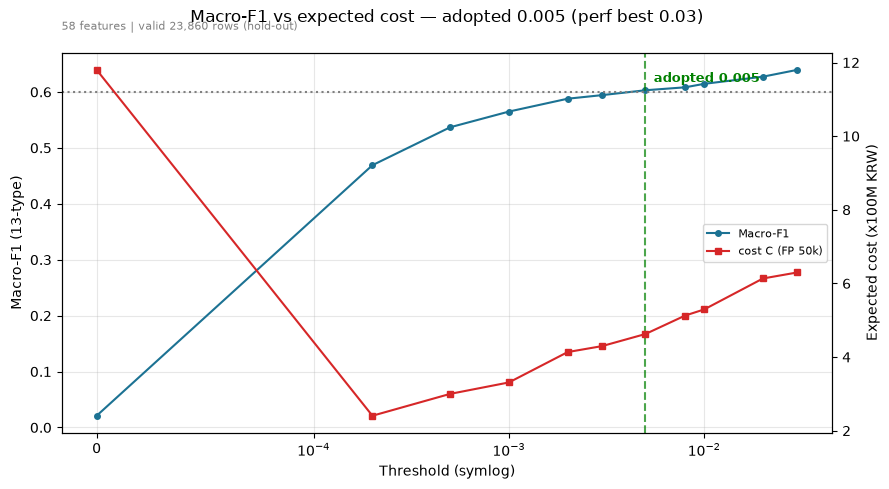

In [ ]:
cname = list(FP_SCENARIOS)[-1]
best_perf = s.loc[s["macro"].idxmax()]
ok = s[s["macro"] >= MACRO_MIN]
pick = ok.loc[ok[cname].idxmin()] if len(ok) else best_perf
print(f"\n[최종 채택] Macro-F1 ≥ {MACRO_MIN} 제약 하 기대비용({cname}) 최소화")
print(f"  → 임계값 {pick['thr']:g} | Macro-F1 {pick['macro']:.4f} | "
      f"미탐 {int(pick['FN'])} 오탐 {int(pick['FP'])} | 비용 {pick[cname]:.2f}억")
print(f"  (성능 최고점: 임계값 {best_perf['thr']:g} → Macro-F1 {best_perf['macro']:.4f}, "
      f"비용 {best_perf[cname]:.2f}억)")
for n_ in FP_SCENARIOS:
    b = s.loc[s[n_].idxmin()]
    print(f"  · {n_} 순수 비용최소: 임계값 {b['thr']:g} (비용 {b[n_]:.2f}억, Macro-F1 {b['macro']:.3f})")

# 비용 vs 성능 그래프
fig, ax1 = plt.subplots(figsize=(9, 5))
l1, = ax1.plot(s["thr"], s["macro"], "-o", ms=4, color="#1C7293", label="Macro-F1")
ax1.set_xscale("symlog", linthresh=1e-4)
ax1.set_xlabel("Threshold (symlog)"); ax1.set_ylabel("Macro-F1 (13-type)")
ax1.axhline(MACRO_MIN, ls=":", color="gray")
ax2 = ax1.twinx()
l2, = ax2.plot(s["thr"], s[cname], "-s", ms=4, color="tab:red", label=f"cost {cname}")
ax2.set_ylabel("Expected cost (x100M KRW)")
ax1.axvline(pick["thr"], ls="--", color="green", alpha=.7)
ax1.annotate(f"adopted {pick['thr']:g}", xy=(pick["thr"], 1.0), xycoords=("data", "axes fraction"),
             xytext=(6, -14), textcoords="offset points", color="green",
             fontsize=9, weight="bold", va="top")
ax1.legend(handles=[l1, l2], loc="center right", fontsize=8)
ax1.set_title(f"Macro-F1 vs expected cost — adopted {pick['thr']:g} "
              f"(perf best {best_perf['thr']:g})", pad=22)
ax1.text(0, 1.06, basis, transform=ax1.transAxes, fontsize=8, color="gray")
ax1.grid(alpha=.3); fig.tight_layout(); plt.show()

## 2-3. FN 단가 고정 가정의 한계 — 유형별 실제 금액으로 재계산

튜터 지적(“1,700만원 고정값 가정의 한계”)에 대한 직접 응답이다.
`i` 유형 평균 피해액은 8,097만원으로 `h` 유형(347만원)의 **23배**다.



[FN 비용: 실제금액 vs 고정값 가정]


,임계값,미탐(FN),FN실제금액(억),FN고정값(억),차이(%)
0,0,0,0.00,0.00,-
1,0.0002,13,3.15,2.21,42.5
2,0.0005,17,4.25,2.89,47.1
3,0.001,19,4.38,3.23,35.6
4,0.002,24,4.86,4.08,19.1
5,0.003,25,4.86,4.25,14.4
6,0.005,27,5.06,4.59,10.2
7,0.008,30,5.24,5.10,2.7
8,0.01,31,5.32,5.27,0.9
9,0.02,36,6.04,6.12,-1.3


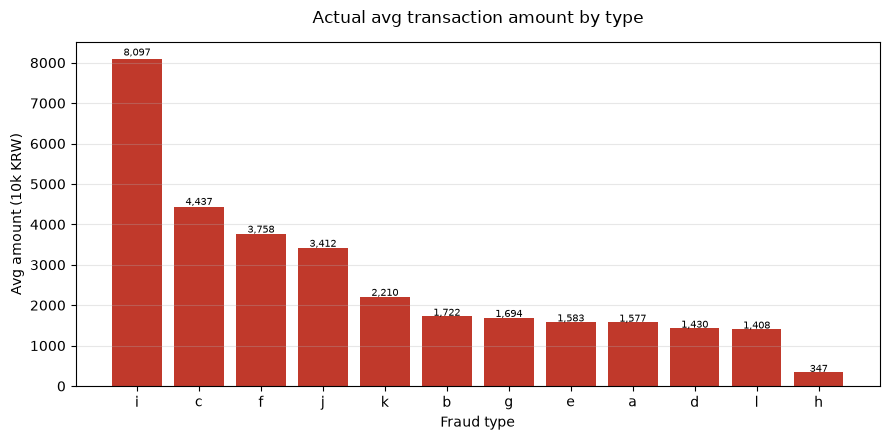

In [ ]:
# FN 실제금액 vs 고정값
if amount is not None:
    fa = s[["thr", "FN", "FN실제금액(억)", "FN고정값(억)"]].copy()
    fa["차이(%)"] = (((fa["FN실제금액(억)"] - fa["FN고정값(억)"]) /
                     fa["FN고정값(억)"].replace(0, np.nan) * 100)
                    .round(1).fillna("-"))      # FN=0이면 비교 불가 → '-'
    fa["thr"] = fa["thr"].map(lambda v: f"{v:g}")
    _table(fa.rename(columns={"thr": "임계값", "FN": "미탐(FN)"}),
           "FN 비용: 실제금액 vs 고정값 가정")
    types = [c for c in classes if c != normal_idx]
    avg = sorted([(lab(c), amount[y_arr == c].mean() / 1e4) for c in types], key=lambda t: -t[1])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    b = ax.bar([a for a, _ in avg], [v for _, v in avg], color="#c0392b")
    for r, (_, v) in zip(b, avg):
        ax.text(r.get_x() + r.get_width()/2, r.get_height() * 1.01, f"{v:,.0f}",
                ha="center", fontsize=7)
    ax.set_xlabel("Fraud type"); ax.set_ylabel("Avg amount (10k KRW)")
    ax.set_title("Actual avg transaction amount by type", pad=14)
    ax.grid(axis="y", alpha=.3); fig.tight_layout(); plt.show()

## 2-4. 붕괴 지점 정밀 스캔 — 붕괴는 '구간'이 아니라 '한 점'

임계값 0 에서 Macro-F1 이 0.021 로 붕괴한다. 이것이 넓은 구간인지 한 점인지 확인한다.


In [ ]:
# 붕괴 정밀 스캔
col = thr_scan(THR_COLLAPSE).sort_values("thr")[["thr", "macro", "FN", "FP"]]
col["thr"] = col["thr"].map(lambda v: f"{v:.6f}")
_table(col.rename(columns={"thr": "임계값", "macro": "Macro-F1",
                           "FN": "미탐(FN)", "FP": "오탐(FP)"}),
       "붕괴 지점 정밀 스캔 (0 ~ 0.0002)")
print("  ※ 임계값은 소수 6자리 — 0의 개수 주의(0.000010=십만분의1, 0.000100=만분의1)")
print("  → 붕괴는 '구간'이 아니라 임계값 0 한 점에서만 발생(risk≥0이면 전량 사기 판정)")


[붕괴 지점 정밀 스캔 (0 ~ 0.0002)]


,임계값,Macro-F1,미탐(FN),오탐(FP)
0,0.000000,0.0210,0,23602
1,0.000010,0.2659,1,1810
2,0.000020,0.3028,3,1348
3,0.000050,0.3633,5,832
4,0.000100,0.4194,7,578
5,0.000150,0.4505,8,459
6,0.000200,0.4690,13,389


  ※ 임계값은 소수 6자리 — 0의 개수 주의(0.000010=십만분의1, 0.000100=만분의1)
  → 붕괴는 '구간'이 아니라 임계값 0 한 점에서만 발생(risk≥0이면 전량 사기 판정)


### 최종 채택

| 항목 | 값 |
|---|---|
| **채택 임계값** | **0.005** |
| Macro-F1 | 0.6030 (제약 0.60 충족) |
| 미탐 / 오탐 | 27건 / 69건 |
| 기대비용 (FP 5만원) | **4.62억** |
| 성능 최고점(참고) | 0.03 → Macro-F1 0.6395, 비용 6.30억 |

성능 최고점(0.03)을 쓰지 않은 이유는 비용이 6.30억으로 **1.68억 더 비싸기 때문**이다.
Macro-F1 은 0.0365 오르지만 그 대가가 1.68억이다.
